In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suvidyasonawane/house-price-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/suvidyasonawane/house-price-prediction-dataset


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/kaggle/input/datasets/suvidyasonawane/house-price-prediction-dataset/house_prices_practice.csv")

In [5]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [6]:
df.shape

(300, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [8]:
df.isnull().sum().sort_values(ascending=False)

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# so there is no duplicated and null values

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,300.0,150.500000,86.746758,1.0,75.75,150.5,225.25,300.0
OverallQual,300.0,5.326667,2.873001,1.0,3.00,5.0,8.00,10.0
GrLivArea,300.0,2307.386667,1042.561303,504.0,1392.25,2265.5,3306.50,3998.0
GarageCars,300.0,1.330000,1.109898,0.0,0.00,1.0,2.00,3.0
TotalBsmtSF,300.0,1468.796667,672.333705,303.0,903.00,1502.0,2129.50,2492.0
YearBuilt,300.0,1986.163333,21.377089,1950.0,1967.00,1986.0,2004.25,2023.0
FullBath,300.0,1.523333,1.131543,0.0,0.00,2.0,3.00,3.0
BedroomAbvGr,300.0,2.926667,1.456604,1.0,2.00,3.0,4.00,5.0
LotArea,300.0,8969.453333,3753.531132,2009.0,5996.25,9031.0,12316.00,14987.0
SalePrice,300.0,252262.903333,74998.055214,82494.0,190355.25,251292.5,307105.00,435291.0


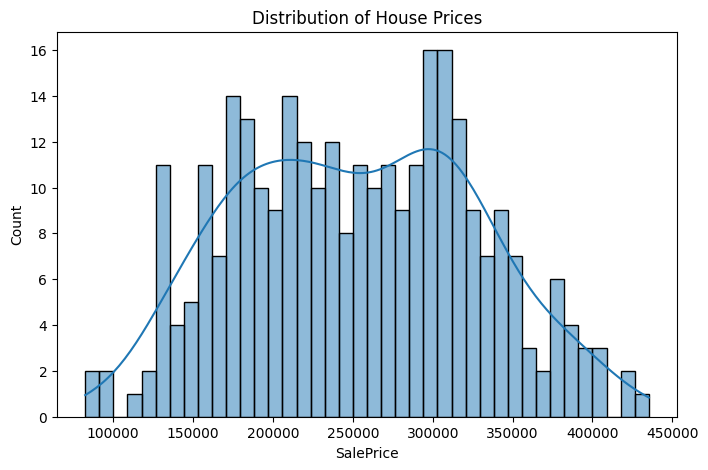

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'],bins=40,kde=True)

plt.title("Distribution of House Prices")

plt.show()

In [12]:
X = df.drop("SalePrice",axis=1)

y = df["SalePrice"]

In [13]:
cat_cols = X.select_dtypes(include='object').columns

num_cols = X.select_dtypes(exclude='object').columns

In [14]:
num_transformer = Pipeline(

[
('imputer',SimpleImputer(strategy='median'))

]

)

In [15]:
cat_transformer = Pipeline(

[
('imputer',SimpleImputer(strategy='most_frequent')),

('encoder',OneHotEncoder(handle_unknown='ignore'))

]

)

In [16]:
preprocessor = ColumnTransformer(

[
('num',num_transformer,num_cols),

('cat',cat_transformer,cat_cols)

]

)

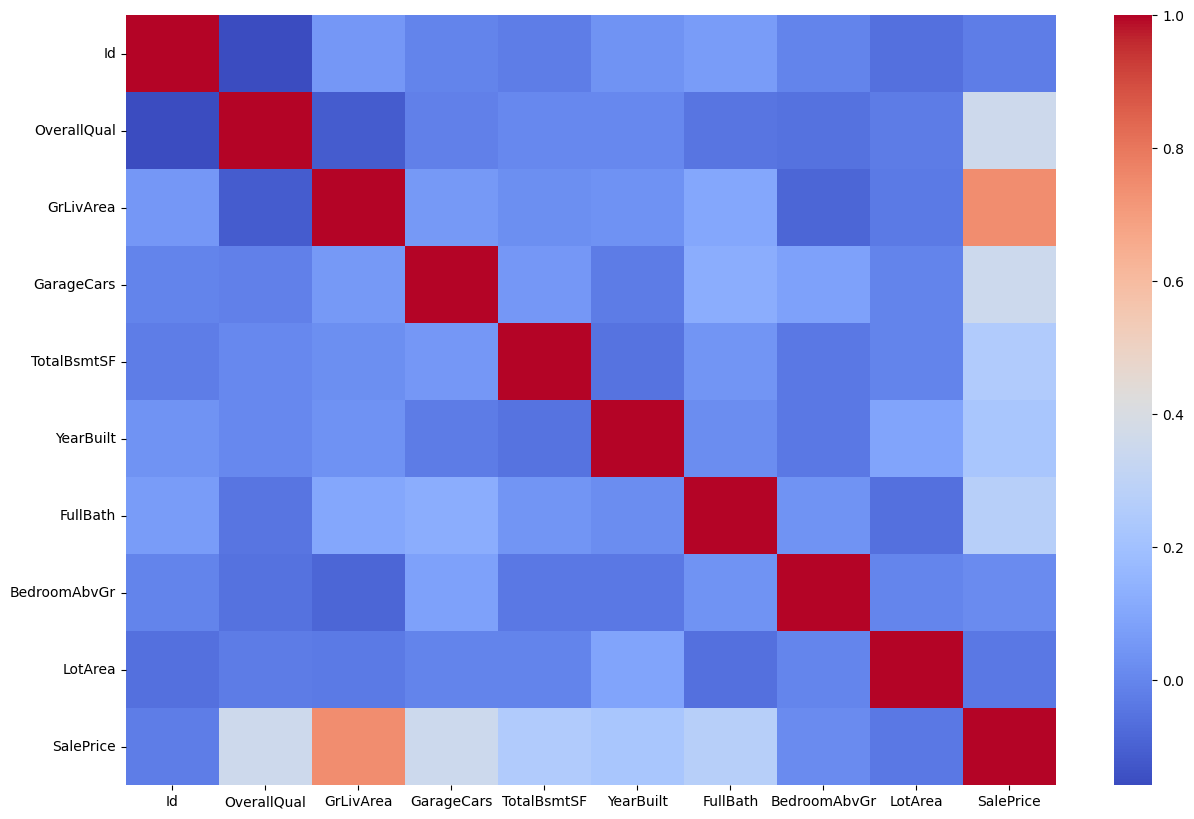

In [17]:
plt.figure(figsize=(15,10))

corr=df.corr(numeric_only=True)

sns.heatmap(corr,cmap='coolwarm')

plt.show()

In [18]:
corr['SalePrice'].sort_values(ascending=False)

SalePrice       1.000000
GrLivArea       0.745095
OverallQual     0.352899
GarageCars      0.351321
FullBath        0.273731
TotalBsmtSF     0.250178
YearBuilt       0.222142
BedroomAbvGr    0.014113
Id             -0.025416
LotArea        -0.038982
Name: SalePrice, dtype: float64

In [22]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.20,
random_state=42

)

In [23]:
model=Pipeline(

[

('preprocessor',preprocessor),

('regressor',LinearRegression())

]

)

In [24]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('regressor', LinearRegression())])

In [25]:
y_pred=model.predict(X_test)

In [26]:
mse=mean_squared_error(y_test,y_pred)

In [27]:
rmse=np.sqrt(mse)

In [28]:
r2=r2_score(y_test,y_pred)

In [29]:
print("MSE :",mse)

print("RMSE :",rmse)

print("R2 :",r2)

MSE : 156388404.64639777
RMSE : 12505.534960424435
R2 : 0.972436661546188


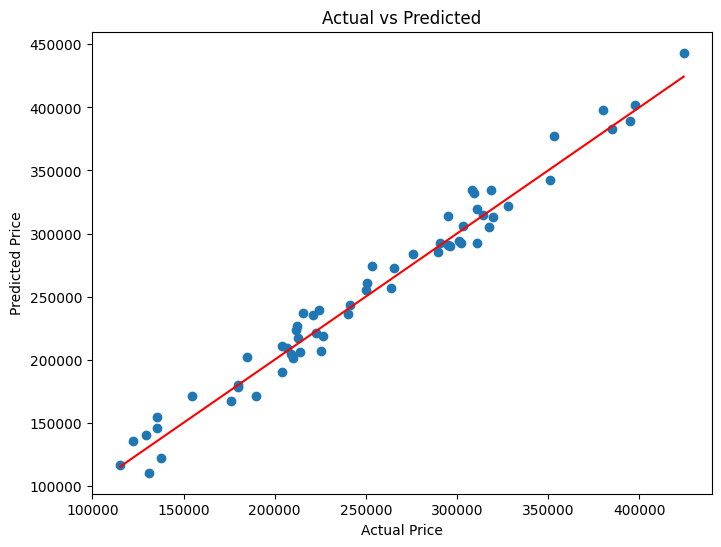

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.plot(

[y_test.min(),y_test.max()],

[y_test.min(),y_test.max()],

color='red'

)

plt.show()

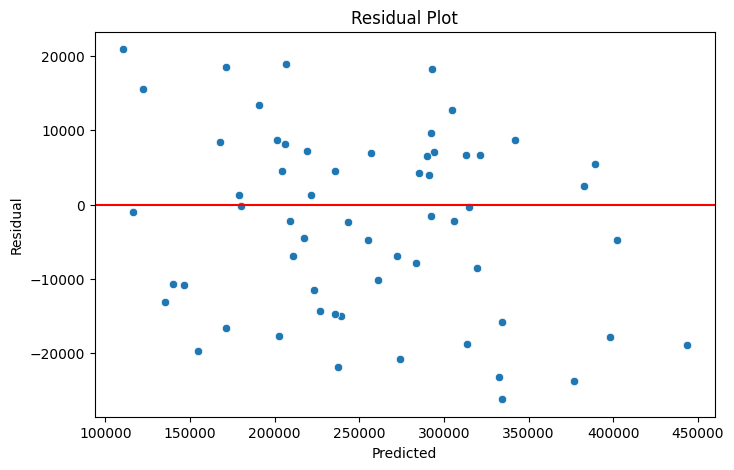

In [31]:
residuals=y_test-y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred,y=residuals)

plt.axhline(0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [33]:
import pickle

pickle.dump(model,open("linear_regression.pkl","wb"))